In [93]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS

In [94]:
from sklearn.datasets import load_breast_cancer

In [95]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns = data.feature_names)
df['target'] = data.target
df_clean = df.dropna()

In [96]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean.drop(columns = ['target']))
X_scaled
y = df_clean['target']

In [97]:
mds = MDS(n_components = 2, random_state = 1, n_jobs = -1)
X_mds = mds.fit_transform(X_scaled)

c:\Users\shaji\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


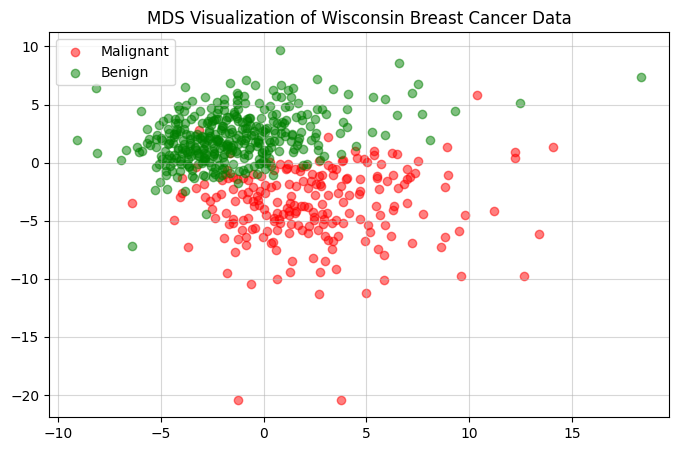

In [98]:
plt.figure(figsize = (8, 5))
for label, color in zip ([0,1], ['red', 'green']):
    plt.scatter(X_mds[y == label, 0], X_mds[y==label, 1], label = 'Malignant' if label ==0 else "Benign", color = color, alpha = 0.5)

plt.title("MDS Visualization of Wisconsin Breast Cancer Data")
plt.legend()
plt.grid(alpha=0.5)
plt.show()

---

In [99]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS

In [100]:
path = "datasets/SpotifyAudioFeatures.csv"
data2 = pd.read_csv(path)
data2.head()

,artist_name,track_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity
0,YG,2RM4jf1Xa9zPgMGRDiht8O,"Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj",0.005820,0.743,238373,0.339,0.000,1,0.0812,-7.678,1,0.4090,203.927,4,0.118,15
1,YG,1tHDG53xJNGsItRA3vfVgs,BAND DRUM (feat. A$AP Rocky),0.024400,0.846,214800,0.557,0.000,8,0.2860,-7.259,1,0.4570,159.009,4,0.371,0
2,R3HAB,6Wosx2euFPMT14UXiWudMy,Radio Silence,0.025000,0.603,138913,0.723,0.000,9,0.0824,-5.890,0,0.0454,114.966,4,0.382,56
3,Chris Cooq,3J2Jpw61sO7l6Hc7qdYV91,Lactose,0.029400,0.800,125381,0.579,0.912,5,0.0994,-12.118,0,0.0701,123.003,4,0.641,0
4,Chris Cooq,2jbYvQCyPgX3CdmAzeVeuS,Same - Original mix,0.000035,0.783,124016,0.792,0.878,7,0.0332,-10.277,1,0.0661,120.047,4,0.928,0


In [101]:
FEATURE_COLUMNS = ['acousticness', 'instrumentalness', 'liveness', 'speechiness', 'tempo', 'popularity']
X = data2[FEATURE_COLUMNS]
y = data2['energy']

X.head()

,acousticness,instrumentalness,liveness,speechiness,tempo,popularity
0,0.005820,0.000,0.0812,0.4090,203.927,15
1,0.024400,0.000,0.2860,0.4570,159.009,0
2,0.025000,0.000,0.0824,0.0454,114.966,56
3,0.029400,0.912,0.0994,0.0701,123.003,0
4,0.000035,0.878,0.0332,0.0661,120.047,0


In [102]:
scaler2 = StandardScaler()
X_scaled = scaler2.fit_transform(X)

print(X_scaled.shape, y.shape)

(130663, 6) (130663,)


In [103]:
X_inp = X[:1000]
y_inp = y[:1000]

print(X_inp.shape, y_inp.shape)

(1000, 6) (1000,)


In [104]:
mds2 = MDS(n_components = 2, random_state = 1, n_jobs = -1 )
X_mds2 = mds2.fit_transform(X_inp)

c:\Users\shaji\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


ValueError: 'c' argument has 1000 elements, which is inconsistent with 'x' and 'y' with size 569.

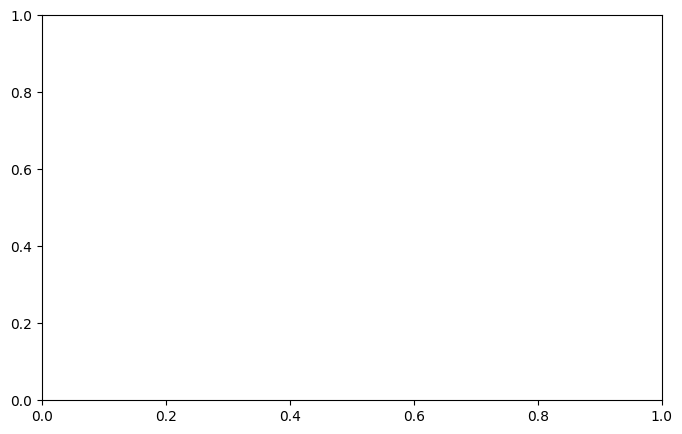

In [105]:
plt.figure(figsize= (8,5))
plt.scatter(X_mds[:,0], X_mds[:,1], c = y_inp, cmap = 'Viridis', alpha = 0.5)
plt.title("Spotify")
plt.legend()
plt.grid(alpha=0.5)
plt.show()